In [85]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel


In [86]:
from transformers import ClapProcessor, ClapModel


In [87]:
import librosa


In [88]:
import torch

In [89]:
import torch.nn as nn

In [90]:
from torch.utils.data import DataLoader

In [91]:
import numpy as np

In [92]:
from datasets import load_from_disk

ds = load_from_disk("../01_load_dataset/musiccaps/dataset_audio")
len(ds)

# preliminary results
# framework direkt metric output edicek
# machine translation metrics, BLEU, ROUGE, METEOR, CIDEr, bertscore

Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

5310

In [93]:
ds_split = ds.train_test_split(test_size=0.1, seed=42)
ds_train = ds_split["train"]
ds_val = ds_split["test"]

In [94]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

# CLAP (frozen)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clap = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap.eval()
for p in clap.parameters():
    p.requires_grad = False

# GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

gpt2 = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2.eval()
for p in gpt2.parameters():
    p.requires_grad = False
    
# T5
# musicgen

/Users/aliozkaya/miniconda3/envs/audio-caption/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [95]:
D_AUDIO = clap.config.projection_dim      # e.g. 512
D_LM = gpt2.config.n_embd                 # 768
PREFIX_LEN = 8

# projection = nn.Linear(D_AUDIO, PREFIX_LEN * D_LM).to(device)
# projection.train()

In [96]:
projection = nn.Sequential(
    nn.Linear(D_AUDIO, D_LM * 4),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(D_LM * 4, PREFIX_LEN * D_LM),
).to(device)
projection.train()

Sequential(
  (0): Linear(in_features=512, out_features=3072, bias=True)
  (1): GELU(approximate='none')
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=3072, out_features=6144, bias=True)
)

In [ ]:
projection = nn.Sequential(
    nn.Linear(D_AUDIO, D_LM * 2),      # 512 → 1536
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(D_LM * 2, D_LM * 4),     # 1536 → 3072
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(D_LM * 4, PREFIX_LEN * D_LM),  # 3072 → PREFIX_LEN * 768
).to(device)
projection.train()

In [101]:
optimizer = torch.optim.AdamW(
    list(projection.parameters()),
    lr=5e-4,
    weight_decay=0.1
)


In [102]:
def get_audio_embedding(sample):
    audio = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if sr != 48000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=48000)

    inputs = clap_processor(
        audios=audio,
        sampling_rate=48000,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        emb = clap.get_audio_features(**inputs)

    return emb  # (1, D_AUDIO)


In [103]:
def train_step(sample):
    audio_emb = get_audio_embedding(sample)     # (1, D_AUDIO)

    # Projection → prefix tokens
    prefix = projection(audio_emb)
    prefix = prefix.view(1, PREFIX_LEN, D_LM)

    # Tokenize caption
    tokens = tokenizer(
        sample["caption"],
        return_tensors="pt"
    ).to(device)

    input_ids = tokens.input_ids                 # (1, T)

    # Text embeddings
    text_embeds = gpt2.transformer.wte(input_ids)

    # Concatenate prefix + text
    inputs_embeds = torch.cat([prefix, text_embeds], dim=1)

    # Labels (ignore prefix)
    labels = input_ids.clone()
    ignore = torch.full((1, PREFIX_LEN), -100, device=device)
    labels = torch.cat([ignore, labels], dim=1)

    outputs = gpt2(
        inputs_embeds=inputs_embeds,
        labels=labels
    )

    return outputs.loss


In [ ]:
from tqdm import tqdm

EPOCHS = 30

all_train_losses = []
all_val_losses = []
epoch_train_losses = []
epoch_val_losses = []

for epoch in tqdm(range(EPOCHS), desc="Training"):
    # ============ TRAINING ============
    projection.train()  # set to train mode
    total_train_loss = 0.0
    valid_samples = 0

    for i in tqdm(range(len(ds_train)), desc="Train", leave=False):
        try:
            optimizer.zero_grad()
            loss = train_step(ds_train[i])
            loss.backward()
            optimizer.step()
            
            all_train_losses.append(loss.item())
            total_train_loss += loss.item()
            valid_samples += 1
        except RuntimeError as e:
            if "No audio frames were decoded" in str(e):
                continue
            raise e

    avg_train_loss = total_train_loss / valid_samples
    epoch_train_losses.append(avg_train_loss)

    # ============ VALIDATION ============
    projection.eval()  # set to eval mode
    total_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():  # no gradients needed for validation
        for i in tqdm(range(len(ds_val)), desc="Val", leave=False):
            try:
                loss = train_step(ds_val[i])  # same forward pass, no backward
                all_val_losses.append(loss.item())
                total_val_loss += loss.item()
                val_samples += 1
            except RuntimeError:
                continue

    avg_val_loss = total_val_loss / val_samples
    epoch_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

Training:   3%|▎         | 1/30 [06:57<3:21:51, 417.64s/it]

Epoch 1: train_loss=2.8583, val_loss=2.7952


Training:   7%|▋         | 2/30 [13:50<3:13:41, 415.06s/it]

Epoch 2: train_loss=2.7521, val_loss=2.7356


Training:  10%|█         | 3/30 [20:35<3:04:40, 410.40s/it]

...

Epoch 13: train_loss=2.5679, val_loss=2.6839


Training:  47%|████▋     | 14/30 [1:36:01<1:52:30, 421.89s/it]

Epoch 14: train_loss=2.5615, val_loss=2.6838


Training:  50%|█████     | 15/30 [1:42:52<1:44:40, 418.67s/it]

Epoch 15: train_loss=2.5579, val_loss=2.6909


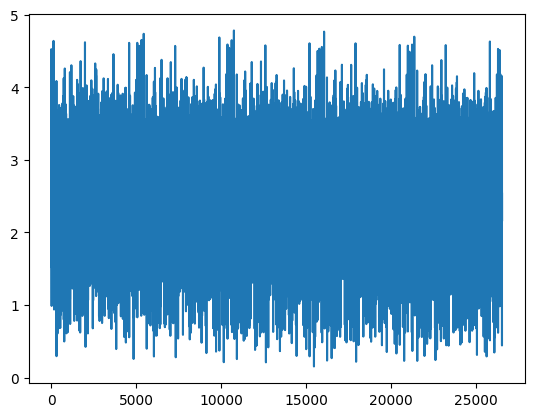

In [42]:
from matplotlib import pyplot as plt

plt.plot(all_losses)
plt.show()


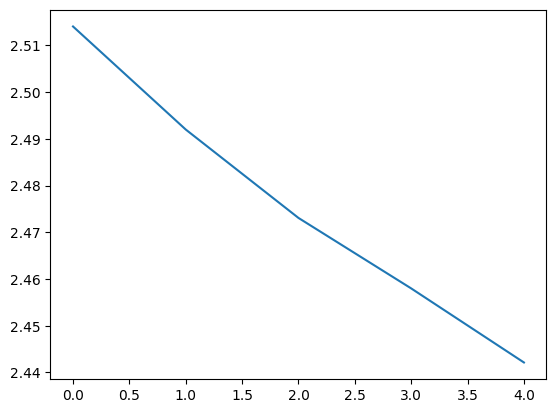

In [43]:
plt.plot(epoch_losses)
plt.show()


In [60]:
gpt2.eval()

sample = ds[0]
audio_emb = get_audio_embedding(sample)

prefix = projection(audio_emb).view(1, PREFIX_LEN, D_LM)

generated = gpt2.generate(
    inputs_embeds=prefix,
    max_length=50
)

print(tokenizer.decode(generated[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The low quality recording features a mellow piano melody accompanied by a soft piano melody. It sounds mellow, emotional and soothing. It sounds soothing, soothing and soothing. It sounds soothing, soothing and soothing.


In [61]:
generated = gpt2.generate(
    inputs_embeds=prefix,
    max_length=100,
    do_sample=True,          # Enable sampling
    temperature=0.8,         # Add randomness (0.7-1.0)
    top_k=50,                # Only sample from top 50 tokens
    top_p=0.9,               # Nucleus sampling
    repetition_penalty=1.2,  # Penalize repetition
    no_repeat_ngram_size=3,  # Prevent 3-gram repetition
)
print(tokenizer.decode(generated[0], skip_special_tokens=True))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


swingers are playing a song that is slow and relaxed with strings as the melody. The tempo changes gradually until it reaches 5:30 in this moment when there's more than one chord per note being played along with some percussion notes on top of those instruments, including flute bass at midrange, cymbals coming from below or above (high pitch), piano chords starting out softening around 9-10 seconds into the chorus to end off an exciting mel


In [ ]:
from IPython.display import Audio
Audio(ds[0]["audio"]["array"], rate=ds[0]["audio"]["sampling_rate"])

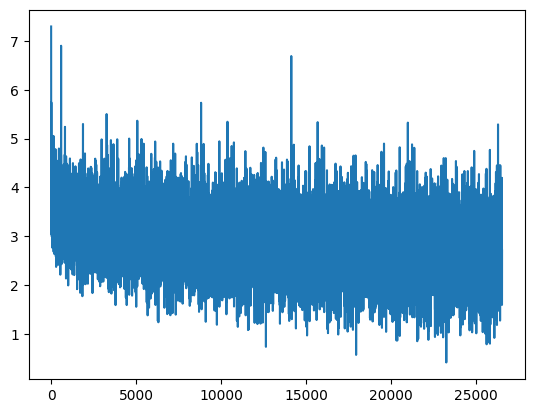

In [58]:
plt.plot(all_losses)
plt.show()

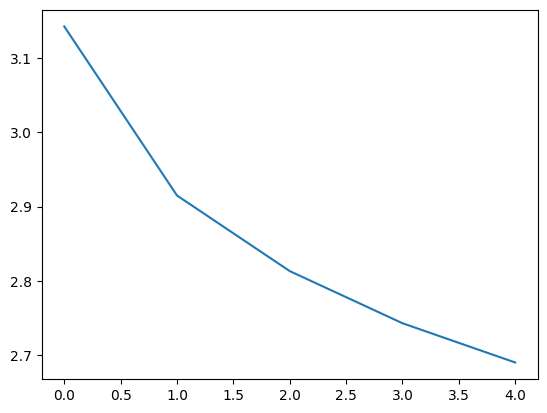

In [59]:
plt.plot(epoch_losses)
plt.show()

In [ ]:
# ============ STAGE 2: Unfreeze GPT-2 ============

# Unfreeze GPT-2
for p in gpt2.parameters():
    p.requires_grad = True
gpt2.train()
projection.train()

# New optimizer with different LRs
optimizer = torch.optim.AdamW([
    {"params": projection.parameters(), "lr": 1e-4},
    {"params": gpt2.parameters(), "lr": 5e-6},
], weight_decay=0.1)

EPOCHS_STAGE2 = 10
best_val_loss = float('inf')

for epoch in tqdm(range(EPOCHS_STAGE2), desc="Stage 2"):
    # ---- Training ----
    projection.train()
    gpt2.train()
    total_train_loss = 0.0
    train_samples = 0

    for i in tqdm(range(len(ds_train)), desc="Train", leave=False):
        try:
            optimizer.zero_grad()
            loss = train_step(ds_train[i])
            loss.backward()          # gradients for projection AND gpt2
            optimizer.step()         # updates projection at 1e-4, gpt2 at 5e-6
            
            total_train_loss += loss.item()
            train_samples += 1
        except RuntimeError:
            continue

    avg_train_loss = total_train_loss / train_samples

    # ---- Validation ----
    projection.eval()
    gpt2.eval()
    total_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():
        for i in tqdm(range(len(ds_val)), desc="Val", leave=False):
            try:
                loss = train_step(ds_val[i])
                total_val_loss += loss.item()
                val_samples += 1
            except RuntimeError:
                continue

    avg_val_loss = total_val_loss / val_samples
    
    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}, val={avg_val_loss:.4f}")
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'projection': projection.state_dict(),
            'gpt2': gpt2.state_dict(),
        }, 'best_model_stage2.pt')
        print(f"  ↳ Saved best model!")